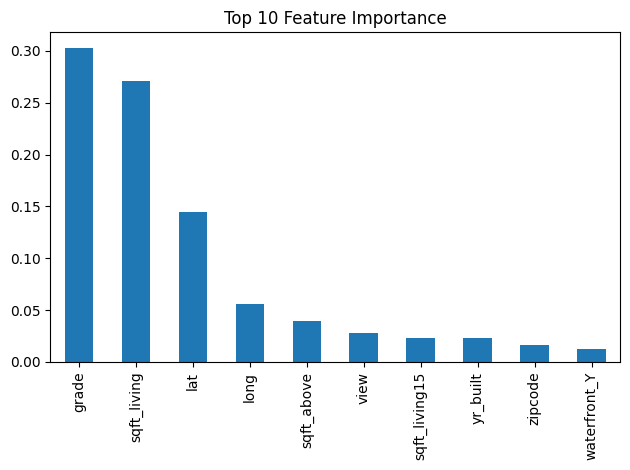

In [2]:
# =========================
# RQ4: Feature Importance (FAST VERSION)
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

DATA_PATH = "/kaggle/input/datasets/alyelbadry/house-pricing-dataset/house_prices.csv"

# Load and reduce size
df = pd.read_csv(DATA_PATH).dropna()
df = df.sample(n=5000, random_state=42)  # 🔥 speed boost

# Prepare data
X = pd.get_dummies(df.drop("price", axis=1))
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Faster model
model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
top = importance.sort_values(ascending=False).head(10)

# Save table
top.to_csv("RQ4_table.csv")

# Plot
plt.figure()
top.plot(kind='bar')
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.savefig("RQ4_figure.pdf")
plt.show()